# Compare X9train (burn-in) vs X8test

For every dataset that has both `X9train` and `X8test`, this notebook loads the two matrices,
takes the first `T = min(len(X9train), len(X8test))` timesteps, and computes the per-timestep
L2 norm of their difference as well as the overall Frobenius norm.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

from ctf4science.data_module import _load_data_file

repo_root = Path("..")
data_root = repo_root / "data"

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [2]:
def find_x9train_x8test(dataset_name: str) -> tuple[Path | None, Path | None]:
    """Return paths to X9train and X8test files for a dataset, or None if absent."""
    yaml_path = data_root / dataset_name / f"{dataset_name}.yaml"
    if not yaml_path.exists():
        return None, None

    with open(yaml_path) as f:
        config = yaml.safe_load(f)

    shapes = config.get("metadata", {}).get("matrix_shapes", {})
    x9_name = next((k for k in shapes if "X9train" in k), None)
    x8_name = next((k for k in shapes if "X8test" in k), None)

    x9_path = data_root / dataset_name / "train" / x9_name if x9_name else None
    x8_path = data_root / dataset_name / "test" / x8_name if x8_name else None

    # Verify files exist on disk
    if x9_path and not x9_path.exists():
        x9_path = None
    if x8_path and not x8_path.exists():
        x8_path = None

    return x9_path, x8_path


# Collect all datasets that have both files
datasets = sorted(p.name for p in data_root.iterdir() if p.is_dir())
valid = {}
for ds in datasets:
    x9, x8 = find_x9train_x8test(ds)
    if x9 and x8:
        valid[ds] = (x9, x8)
        print(f"{ds:20s}  X9train={x9.name}  X8test={x8.name}")

ODE_Lorenz            X9train=X9train.mat  X8test=X8test.mat
PDE_KS                X9train=X9train.mat  X8test=X8test.mat
msfr                  X9train=X9train.npz  X8test=X8test.npz
sst                   X9train=X9train.npy  X8test=X8test.npy
sst_kaggle            X9train=X9train.npy  X8test=X8test.npy


In [3]:
results = {}  # dataset -> {"T": int, "l2_per_t": array, "frob": float, "shape": tuple}

for ds, (x9_path, x8_path) in valid.items():
    x9 = _load_data_file(x9_path).astype(float)
    x8 = _load_data_file(x8_path).astype(float)

    T = min(x9.shape[0], x8.shape[0])
    x9_t = x9[:T]
    x8_t = x8[:T]

    diff = x9_t - x8_t

    # Per-timestep L2 norm: ||diff[t, :]||_2 for each t
    l2_per_t = np.linalg.norm(diff.reshape(T, -1), axis=1)

    # Overall Frobenius norm (= L2 norm of flattened difference)
    frob = float(np.linalg.norm(diff))

    results[ds] = {
        "T": T,
        "l2_per_t": l2_per_t,
        "frob": frob,
        "x9_shape": x9.shape,
        "x8_shape": x8.shape,
    }
    print(f"{ds:20s}  T={T:4d}  frob={frob:.4e}  x9={x9.shape}  x8={x8.shape}")

ODE_Lorenz            T= 100  frob=2.6199e+02  x9=(100, 3)  x8=(1000, 3)
PDE_KS                T= 100  frob=4.3629e+02  x9=(100, 1024)  x8=(1000, 1024)
msfr                  T= 500  frob=1.0030e+03  x9=(500, 19400)  x8=(500, 19400)
sst                   T= 100  frob=1.3973e+04  x9=(100, 90601)  x8=(400, 90601)
sst_kaggle            T= 100  frob=1.4211e+04  x9=(100, 90601)  x8=(400, 90601)


## Per-timestep L2 norm

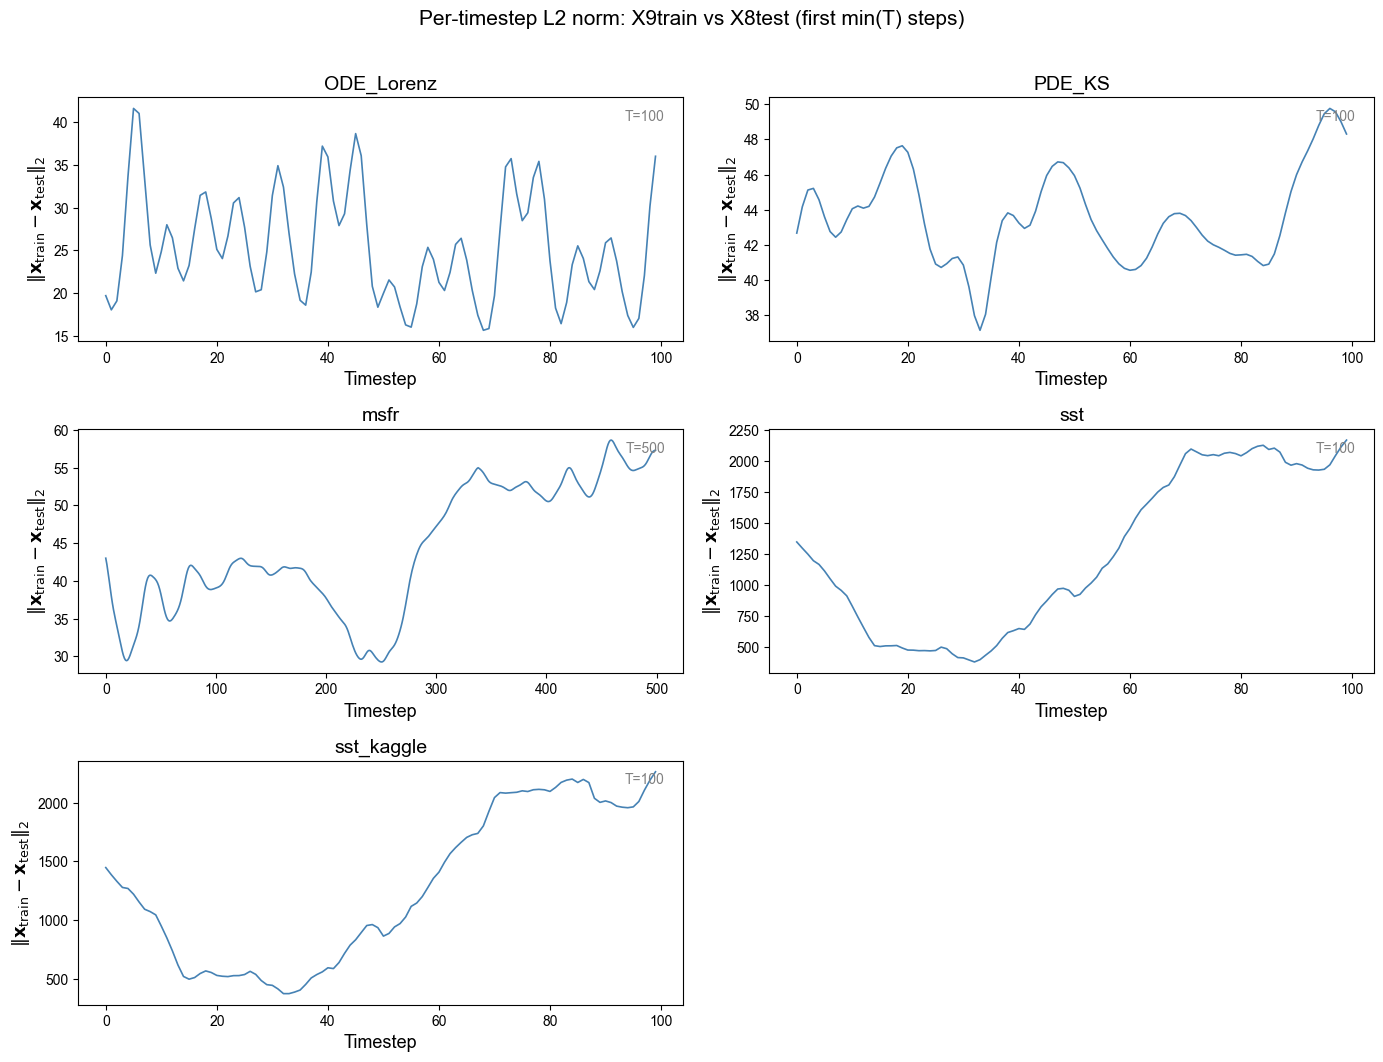

In [4]:
n_ds = len(results)
ncols = 2
nrows = (n_ds + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), squeeze=False)

for ax, (ds, r) in zip(axes.flat, results.items()):
    ax.plot(r["l2_per_t"], color="steelblue", linewidth=1.2)
    ax.set_title(ds)
    ax.set_xlabel("Timestep")
    ax.set_ylabel(r"$\|\mathbf{x}_{\mathrm{train}} - \mathbf{x}_{\mathrm{test}}\|_2$")
    ax.text(
        0.97, 0.95,
        f"T={r['T']}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10, color="gray",
    )

# Hide unused subplots
for ax in axes.flat[n_ds:]:
    ax.set_visible(False)

fig.suptitle("Per-timestep L2 norm: X9train vs X8test (first min(T) steps)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Overall Frobenius norm across datasets

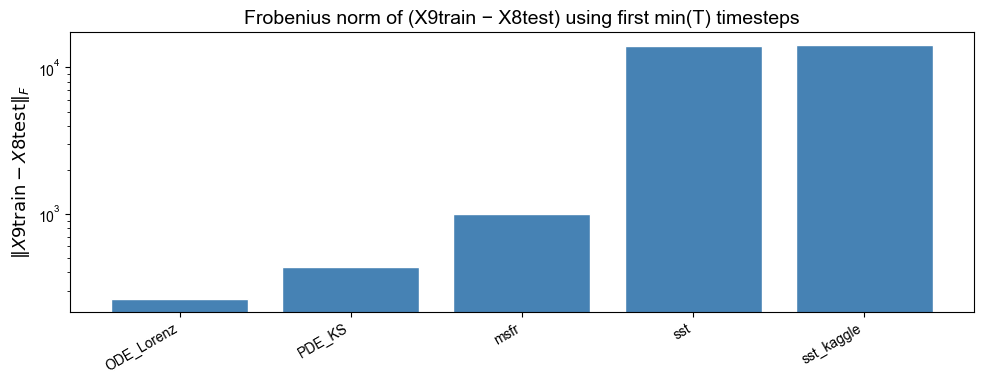

In [5]:
ds_names = list(results.keys())
frob_vals = [results[ds]["frob"] for ds in ds_names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(ds_names, frob_vals, color="steelblue", edgecolor="white")
ax.set_ylabel(r"$\|X9\mathrm{train} - X8\mathrm{test}\|_F$")
ax.set_title("Frobenius norm of (X9train − X8test) using first min(T) timesteps")
ax.set_yscale("log")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Summary table

In [6]:
print(f"{'Dataset':<20} {'X9train shape':<20} {'X8test shape':<20} {'T used':>6} {'Frobenius norm':>18} {'Mean per-t L2':>15}")
print("-" * 104)
for ds, r in results.items():
    print(
        f"{ds:<20} {str(r['x9_shape']):<20} {str(r['x8_shape']):<20}"
        f" {r['T']:>6} {r['frob']:>18.4e} {r['l2_per_t'].mean():>15.4e}"
    )

Dataset              X9train shape        X8test shape         T used     Frobenius norm   Mean per-t L2
--------------------------------------------------------------------------------------------------------
ODE_Lorenz           (100, 3)             (1000, 3)               100         2.6199e+02      2.5449e+01
PDE_KS               (100, 1024)          (1000, 1024)            100         4.3629e+02      4.3551e+01
msfr                 (500, 19400)         (500, 19400)            500         1.0030e+03      4.4051e+01
sst                  (100, 90601)         (400, 90601)            100         1.3973e+04      1.2437e+03
sst_kaggle           (100, 90601)         (400, 90601)            100         1.4211e+04      1.2644e+03
